# Single-ligand first-capture assay

This notebook separates initial analyte capture from post-capture residence and rebinding. Each trajectory begins at a uniformly random x–y location on the lattice plane immediately below the bulk escape plane. It terminates at the first successful receptor association or upon crossing back into bulk.

In [36]:
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import UnivariateSpline
from scipy.optimize import curve_fit

import utils.capture_assay as capture_assay_module
import utils.capture_assay_viz as capture_viz_module
import utils.generate_geometries as geometry_module
importlib.reload(capture_assay_module)
importlib.reload(capture_viz_module)
importlib.reload(geometry_module)

from utils.biosensor_mc import Params, derive
from utils.capture_assay import run_capture_assay
from utils.capture_assay_viz import (
    export_capture_assay_run,
    load_capture_assay_run,
    plot_capture_surface_3d,
    plot_capture_surface_xy,
    plot_capture_time_distribution,
    plot_capture_vs_surface_height,
    plot_cumulative_capture_and_escape,
    plot_initial_plane_capture_probability,
)
from utils.escape_assay import sample_receptor_faces
from utils.generate_geometries import (
    make_cylindrically_curved_sheet_geometry,
    make_flat_geometry,
    make_sinusoidal_height_field_geometry,
    make_spherical_bowl_geometry,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

## 1. Shared model and reservoir plane

The planar distance control and all candidate geometries below use these same transport, receptor, kinetic, and boundary parameters.

In [32]:
nm = 1e-9
P = Params(
    Lx_m=100 * nm, Ly_m=100 * nm, H_m=200 * nm, a_m=1 * nm,
    D_m2_s=1e-11, receptor_density_m2=5e16, ligand_conc_M=0.0,
    k_on_M_inv_s=1e8, k_off_s=200.0,
    open_boundaries=("z_max",), periodic_axes=("x", "y"), seed=7,
)
escape_z_m = 75 * nm
injection_z_index = int(np.ceil(escape_z_m / P.a_m) - 1)
injection_z_m = injection_z_index * P.a_m
print(
    f"Periodic axes: {P.periodic_axes}; escape plane: {escape_z_m / nm:g} nm; "
    f"injection plane: {injection_z_m / nm:g} nm"
)

Periodic axes: ('x', 'y'); escape plane: 75 nm; injection plane: 74 nm


## 2. Planar distance control

This control keeps a uniformly receptor-coated planar surface fixed and moves the injection/escape interface. Distance is measured from the injection lattice plane to the receptor reaction plane—the fluid layer where association is attempted. Corresponding conditions use the same receptor and trajectory seeds, providing a paired comparison of the interface separation alone.

In [33]:
PLANAR_DISTANCE_N_TRAJECTORIES = 1e4
PLANAR_DISTANCE_MAX_TIME_S = 0.01
# Requested injection-to-receptor reaction-plane separations. With the
# 1 nm lattice these are represented exactly.
PLANAR_BINDING_DISTANCES_NM = np.linspace(10, 100, 10, dtype=int)

planar_geometry = make_flat_geometry(P, surface_z_m=0.0, name="planar_distance_control")
planar_receptor_faces = sample_receptor_faces(P, planar_geometry, seed=P.seed)
planar_reaction_z_index = 1  # The fluid layer immediately above the z=0 solid plane.
planar_distance_results = {}
planar_rows = []
for distance_nm in PLANAR_BINDING_DISTANCES_NM:
    distance_layers = int(round(distance_nm * nm / P.a_m))
    condition_injection_z_index = planar_reaction_z_index + distance_layers
    condition_escape_z_m = (condition_injection_z_index + 1) * P.a_m
    if condition_escape_z_m > P.H_m:
        raise ValueError(
            f"Distance {distance_nm} nm requires escape_z={condition_escape_z_m / nm:g} nm, "
            f"above H={P.H_m / nm:g} nm. Increase P.H_m."
        )
    result = run_capture_assay(
        P, planar_geometry,
        n_trajectories=PLANAR_DISTANCE_N_TRAJECTORIES,
        max_time_s=PLANAR_DISTANCE_MAX_TIME_S,
        escape_z_m=condition_escape_z_m, receptor_face_ids=planar_receptor_faces,
        trajectory_seed=P.seed + 500,
    )
    planar_distance_results[float(distance_nm)] = result
    row = result.condition_summary.iloc[0].to_dict()
    row.update({
        "binding_distance_nm": float(distance_nm),
        "surface_z_nm": 0.0,
        "receptor_reaction_z_nm": planar_reaction_z_index * P.a_m / nm,
        "condition_injection_z_nm": condition_injection_z_index * P.a_m / nm,
        "condition_escape_z_nm": condition_escape_z_m / nm,
    })
    planar_rows.append(row)

planar_distance_summary = pd.DataFrame(planar_rows).sort_values("binding_distance_nm")
display(planar_distance_summary)

print(f"Planar receptor count: {len(planar_receptor_faces):,}")

,n_trajectories,n_captured,n_escaped,n_censored,capture_probability,capture_probability_se,capture_probability_wilson_95_low,capture_probability_wilson_95_high,escape_probability,censoring_fraction,mean_capture_time_given_capture_s,median_capture_time_given_capture_s,mean_escape_time_given_escape_s,mean_termination_time_s,mean_receptor_contact_steps,escape_z_m,injection_z_m,n_receptors,injection_plane_area_m2,delivery_rate_coefficient_M_inv_s,capture_rate_coefficient_M_inv_s,binding_distance_nm,surface_z_nm,receptor_reaction_z_nm,condition_injection_z_nm,condition_escape_z_nm
0,10000.0,548.0,9452.0,0.0,0.0548,0.002276,0.050508,0.059434,0.9452,0.0,0.000004,0.000003,5.471629e-07,7.135925e-07,0.0603,1.200000e-08,1.100000e-08,500.0,1.000000e-14,6.022141e+10,3.300133e+09,10.0,0.0,1.0,11.0,12.0
1,10000.0,338.0,9662.0,0.0,0.0338,0.001807,0.030433,0.037525,0.9662,0.0,0.000011,0.000009,8.767458e-07,1.214019e-06,0.0355,2.200000e-08,2.100000e-08,500.0,1.000000e-14,6.022141e+10,2.035484e+09,20.0,0.0,1.0,21.0,22.0
2,10000.0,254.0,9746.0,0.0,0.0254,0.001573,0.022494,0.028671,0.9746,0.0,0.000022,0.000018,1.154849e-06,1.687716e-06,0.0287,3.200000e-08,3.100000e-08,500.0,1.000000e-14,6.022141e+10,1.529624e+09,30.0,0.0,1.0,31.0,32.0
3,10000.0,197.0,9803.0,0.0,0.0197,0.001390,0.017155,0.022614,0.9803,0.0,0.000033,0.000028,1.475173e-06,2.101189e-06,0.0207,4.200000e-08,4.100000e-08,500.0,1.000000e-14,6.022141e+10,1.186362e+09,40.0,0.0,1.0,41.0,42.0
4,10000.0,158.0,9842.0,0.0,0.0158,0.001247,0.013535,0.018437,0.9842,0.0,0.000050,0.000040,1.819604e-06,2.578859e-06,0.0175,5.200000e-08,5.100000e-08,500.0,1.000000e-14,6.022141e+10,9.514982e+08,50.0,0.0,1.0,51.0,52.0
5,10000.0,137.0,9863.0,0.0,0.0137,0.001162,0.011601,0.016172,0.9863,0.0,0.000076,0.000063,2.130936e-06,3.142765e-06,0.0146,6.200000e-08,6.100000e-08,500.0,1.000000e-14,6.022141e+10,8.250333e+08,60.0,0.0,1.0,61.0,62.0
6,10000.0,117.0,9883.0,0.0,0.0117,0.001075,0.009772,0.014003,0.9883,0.0,0.000091,0.000074,2.455596e-06,3.489542e-06,0.0128,7.200000e-08,7.100000e-08,500.0,1.000000e-14,6.022141e+10,7.045905e+08,70.0,0.0,1.0,71.0,72.0
7,10000.0,103.0,9897.0,0.0,0.0103,0.001010,0.008501,0.012475,0.9897,0.0,0.000119,0.000111,2.652020e-06,3.846751e-06,0.0111,8.200000e-08,8.100000e-08,500.0,1.000000e-14,6.022141e+10,6.202805e+08,80.0,0.0,1.0,81.0,82.0
8,10000.0,88.0,9912.0,0.0,0.0088,0.000934,0.007149,0.010828,0.9912,0.0,0.000146,0.000123,3.084051e-06,4.341636e-06,0.0097,9.200000e-08,9.100000e-08,500.0,1.000000e-14,6.022141e+10,5.299484e+08,90.0,0.0,1.0,91.0,92.0
9,10000.0,79.0,9921.0,0.0,0.0079,0.000885,0.006344,0.009834,0.9921,0.0,0.000163,0.000138,3.181384e-06,4.440127e-06,0.0085,1.020000e-07,1.010000e-07,500.0,1.000000e-14,6.022141e+10,4.757491e+08,100.0,0.0,1.0,101.0,102.0


Planar receptor count: 500


### Fit the planar distance relationship

For one-dimensional diffusion between a return boundary and a partially reactive plane, the capture committor has the form $P(d)=A/(d+\ell_r)$, where $\ell_r$ is an effective reaction length. This inverse-offset model is the preferred extrapolating model. A weighted smoothing spline is also fitted as a flexible diagnostic, but should only be used inside the calibrated distance range.

,value
amplitude_nm,0.888910
reaction_length_nm,6.143477
reduced_chi_squared,0.119218
r_squared,0.999249


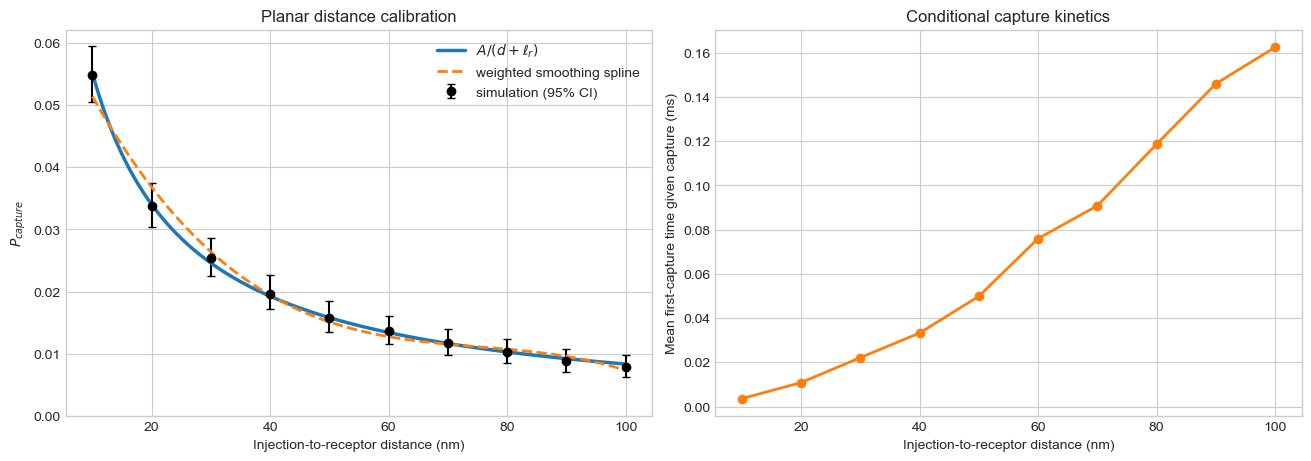

In [37]:
PLANAR_BASELINE_MODEL = "inverse_offset"  # "inverse_offset" or "spline"
planar_x_nm = planar_distance_summary["binding_distance_nm"].to_numpy(float)
planar_y = planar_distance_summary["capture_probability"].to_numpy(float)
planar_sigma = planar_distance_summary["capture_probability_se"].to_numpy(float)
planar_sigma = np.maximum(planar_sigma, 0.5 / PLANAR_DISTANCE_N_TRAJECTORIES)

def inverse_offset_capture(distance_nm, amplitude_nm, reaction_length_nm):
    distance_nm = np.asarray(distance_nm, dtype=float)
    return amplitude_nm / (distance_nm + reaction_length_nm)

inverse_parameters, inverse_covariance = curve_fit(
    inverse_offset_capture, planar_x_nm, planar_y, sigma=planar_sigma,
    absolute_sigma=True, bounds=([0.0, 0.0], [np.inf, np.inf]),
)
planar_spline = UnivariateSpline(
    planar_x_nm, planar_y, w=1.0 / planar_sigma, s=len(planar_x_nm), k=3, ext=2,
)

def planar_capture_baseline(distance_nm, model=PLANAR_BASELINE_MODEL):
    distance_nm = np.asarray(distance_nm, dtype=float)
    if model == "inverse_offset":
        prediction = inverse_offset_capture(distance_nm, *inverse_parameters)
    elif model == "spline":
        if np.any((distance_nm < planar_x_nm.min()) | (distance_nm > planar_x_nm.max())):
            raise ValueError("Spline predictions must remain inside the calibrated distance range.")
        prediction = planar_spline(distance_nm)
    else:
        raise ValueError("Unknown PLANAR_BASELINE_MODEL.")
    return np.clip(prediction, 0.0, 1.0)

inverse_prediction = inverse_offset_capture(planar_x_nm, *inverse_parameters)
weighted_residual = (planar_y - inverse_prediction) / planar_sigma
fit_summary = pd.Series({
    "amplitude_nm": inverse_parameters[0],
    "reaction_length_nm": inverse_parameters[1],
    "reduced_chi_squared": np.sum(weighted_residual**2) / max(len(planar_x_nm) - 2, 1),
    "r_squared": 1 - np.sum((planar_y - inverse_prediction)**2) / np.sum((planar_y - planar_y.mean())**2),
})
display(fit_summary.to_frame("value"))

capture_yerr = np.vstack([
    planar_y - planar_distance_summary["capture_probability_wilson_95_low"],
    planar_distance_summary["capture_probability_wilson_95_high"] - planar_y,
])
fit_x_nm = np.linspace(planar_x_nm.min(), planar_x_nm.max(), 500)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
axes[0].errorbar(planar_x_nm, planar_y, yerr=capture_yerr, fmt="o", capsize=3, color="black", label="simulation (95% CI)")
axes[0].plot(fit_x_nm, inverse_offset_capture(fit_x_nm, *inverse_parameters), linewidth=2.5, label=r"$A/(d+\ell_r)$")
axes[0].plot(fit_x_nm, np.clip(planar_spline(fit_x_nm), 0, 1), linewidth=2, linestyle="--", label="weighted smoothing spline")
axes[0].set(xlabel="Injection-to-receptor distance (nm)", ylabel=r"$P_{capture}$", title="Planar distance calibration", ylim=(0, None))
axes[0].legend()
axes[1].plot(planar_x_nm, planar_distance_summary["mean_capture_time_given_capture_s"] * 1e3, marker="o", linewidth=2, color="tab:orange")
axes[1].set(xlabel="Injection-to-receptor distance (nm)", ylabel="Mean first-capture time given capture (ms)", title="Conditional capture kinetics")
plt.show()

## 3. Matched candidate geometries

All geometries use identical diffusion, intrinsic association kinetics, receptor density, periodic x/y boundaries, and a common bulk escape plane. The sheet edges are fixed at 50 nm and the sinusoidal surface matches the escape-assay study.

In [38]:
bowl_geometry = make_spherical_bowl_geometry(
    P, radius_m=25 * nm, depth_m=25 * nm,
    center_xy_m=(50 * nm, 50 * nm), rim_z_m=50 * nm,
    name="spherical_bowl",
)
sheet_half_span_m = 0.5 * (round(P.Lx_m / P.a_m) - 1) * P.a_m
sheet_radius_m = 55 * nm
sheet_sagitta_m = sheet_half_span_m**2 / (
    sheet_radius_m + np.sqrt(sheet_radius_m**2 - sheet_half_span_m**2)
)
sheet_geometry = make_cylindrically_curved_sheet_geometry(
    P, radius_m=sheet_radius_m, axis="y",
    vertex_z_m=50 * nm - sheet_sagitta_m, name="curved_sheet",
)
sinusoidal_geometry = make_sinusoidal_height_field_geometry(
    P, amplitude_m=15 * nm, wavelength_x_m=50 * nm,
    wavelength_y_m=50 * nm, mean_z_m=25 * nm,
    name="sinusoidal_height_field",
)
geometries = {
    "spherical_bowl": bowl_geometry,
    "curved_sheet": sheet_geometry,
    "sinusoidal_field": sinusoidal_geometry,
}
print(f"Candidate geometries use the shared {injection_z_m / nm:g} nm injection plane.")

Candidate geometries use the shared 74 nm injection plane.


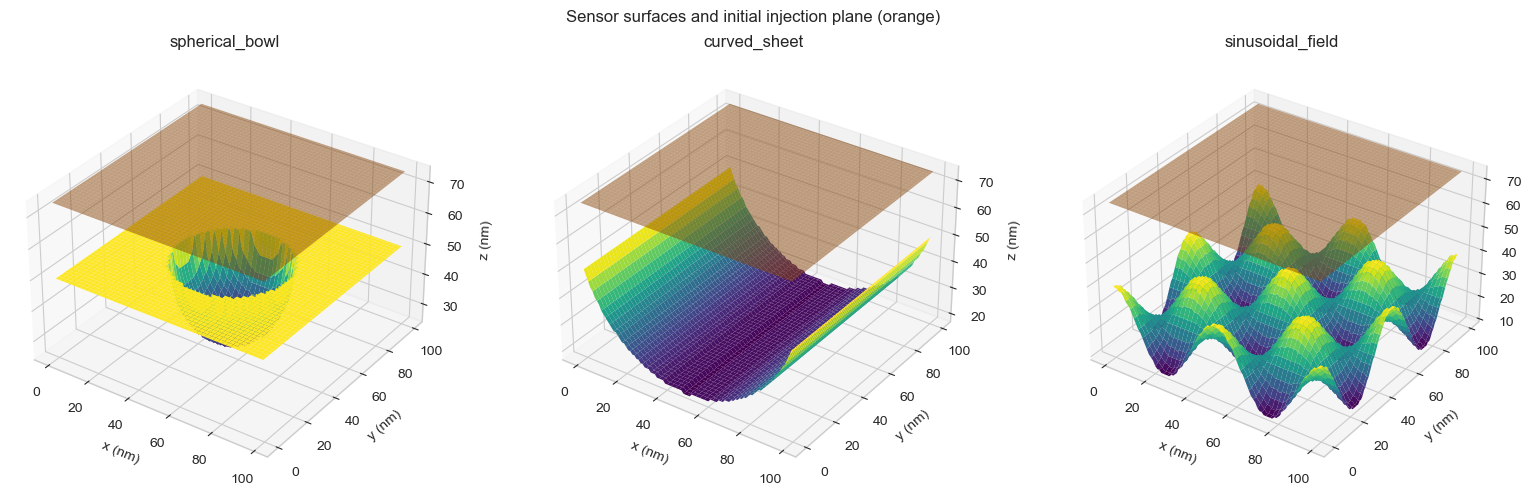

In [39]:
fig = plt.figure(figsize=(16, 5))
for panel, (name, candidate) in enumerate(geometries.items(), 1):
    G_candidate = derive(P, candidate)
    z_indices = np.arange(G_candidate.Nz + 1)[None, None, :]
    height_nm = np.max(np.where(candidate.solid_mask, z_indices, -1), axis=2)
    ax = fig.add_subplot(1, len(geometries), panel, projection="3d")
    x_nm = np.arange(G_candidate.Nx) * P.a_m / nm
    y_nm = np.arange(G_candidate.Ny) * P.a_m / nm
    X_nm, Y_nm = np.meshgrid(x_nm, y_nm, indexing="ij")
    ax.plot_surface(X_nm, Y_nm, height_nm, cmap="viridis", linewidth=0)
    ax.plot_surface(
        X_nm, Y_nm, np.full_like(X_nm, escape_z_m / nm - 1),
        color="tab:orange", alpha=0.5, linewidth=0,
    )
    ax.set(xlabel="x (nm)", ylabel="y (nm)", zlabel="z (nm)", title=name)
    ax.set_box_aspect((1, 1, 0.65))
    ax.view_init(elev=32, azim=-55)
fig.suptitle("Sensor surfaces and initial injection plane (orange)")
plt.tight_layout()
plt.show()

## 4. Run first-capture trajectories

Increase `N_TRAJECTORIES` for production statistics. With `INITIAL_XY_M=None`, every trajectory receives an independent uniformly sampled lateral starting position. Set a coordinate such as `(50*nm, 50*nm)` to study delivery from one location.

In [40]:
N_TRAJECTORIES = 1e7
MAX_TIME_S = 0.01
INITIAL_XY_M = None
RUN_GEOMETRIES = list(geometries)  # Or select a subset, e.g. ["spherical_bowl"]

capture_results = {}
for offset, name in enumerate(RUN_GEOMETRIES):
    candidate = geometries[name]
    receptor_faces = sample_receptor_faces(P, candidate, seed=P.seed)
    capture_results[name] = run_capture_assay(
        P, candidate, n_trajectories=N_TRAJECTORIES, max_time_s=MAX_TIME_S,
        escape_z_m=escape_z_m, initial_xy_m=INITIAL_XY_M,
        receptor_face_ids=receptor_faces, trajectory_seed=P.seed + 1000 + offset,
    )
    summary = capture_results[name].condition_summary.iloc[0]
    print(
        f"{name}: P_capture={summary.capture_probability:.4f}, "
        f"captured={int(summary.n_captured):,}, escaped={int(summary.n_escaped):,}, "
        f"censored={int(summary.n_censored):,}"
    )

spherical_bowl: P_capture=0.0325, captured=325,161, escaped=9,674,839, censored=0
curved_sheet: P_capture=0.0222, captured=221,842, escaped=9,778,158, censored=0
sinusoidal_field: P_capture=0.0208, captured=208,173, escaped=9,791,827, censored=0


In [41]:
comparison = pd.concat(
    [result.condition_summary.assign(geometry=name) for name, result in capture_results.items()],
    ignore_index=True,
).set_index("geometry")
comparison

,n_trajectories,n_captured,n_escaped,n_censored,capture_probability,capture_probability_se,capture_probability_wilson_95_low,capture_probability_wilson_95_high,escape_probability,censoring_fraction,mean_capture_time_given_capture_s,median_capture_time_given_capture_s,mean_escape_time_given_escape_s,mean_termination_time_s,mean_receptor_contact_steps,escape_z_m,injection_z_m,n_receptors,injection_plane_area_m2,delivery_rate_coefficient_M_inv_s,capture_rate_coefficient_M_inv_s
geometry,,,,,,,,,,,,,,,,,,,,,
spherical_bowl,10000000,325161,9674839,0,0.032516,0.000056,0.032406,0.032626,0.967484,0.0,0.000015,0.000012,0.000001,0.000001,0.035056,7.500000e-08,7.400000e-08,699,1.000000e-14,6.022141e+10,1.958165e+09
curved_sheet,10000000,221842,9778158,0,0.022184,0.000047,0.022093,0.022276,0.977816,0.0,0.000037,0.000030,0.000002,0.000002,0.023878,7.500000e-08,7.400000e-08,820,1.000000e-14,6.022141e+10,1.335964e+09
sinusoidal_field,10000000,208173,9791827,0,0.020817,0.000045,0.020729,0.020906,0.979183,0.0,0.000039,0.000033,0.000002,0.000002,0.022371,7.500000e-08,7.400000e-08,1257,1.000000e-14,6.022141e+10,1.253647e+09


## 5. Calculate distance-adjusted local capture enhancement

For each receptor, the observed absolute capture probability is divided by the probability expected for one receptor on a planar surface at the same vertical distance from the injection plane. This removes the calibrated planar distance trend while retaining geometry-dependent accessibility, diffusion, and competition among receptors. Keep the absolute capture maps and total capture probability as the primary results; the enhancement is a mechanistic comparison.

In [42]:
planar_receptor_count = len(planar_receptor_faces)
enhancement_rows = []

for geometry_name, result in capture_results.items():
    receptor_summary = result.receptor_summary
    injection_z_m = float(result.condition_summary.loc[0, "injection_z_m"])
    distances_nm = (injection_z_m - receptor_summary["release_z_m"].to_numpy(float)) / nm

    if np.any(distances_nm < planar_x_nm.min()) or np.any(distances_nm > planar_x_nm.max()):
        raise ValueError(
            f"{geometry_name} contains receptor distances outside the planar calibration range "
            f"[{planar_x_nm.min():.1f}, {planar_x_nm.max():.1f}] nm. "
            "Extend PLANAR_BINDING_DISTANCES_NM before interpreting the enhancement map."
        )

    planar_probability = planar_capture_baseline(distances_nm)
    expected_per_receptor = planar_probability / planar_receptor_count
    receptor_summary["injection_to_receptor_distance_nm"] = distances_nm
    receptor_summary["planar_capture_probability_at_distance"] = planar_probability
    receptor_summary["planar_expected_probability_per_receptor"] = expected_per_receptor
    receptor_summary["local_capture_enhancement"] = np.divide(
        receptor_summary["capture_probability_all_trajectories"].to_numpy(float),
        expected_per_receptor,
        out=np.full_like(expected_per_receptor, np.nan),
        where=expected_per_receptor > 0,
    )

    observed_total = float(result.condition_summary.loc[0, "capture_probability"])
    expected_total = float(expected_per_receptor.sum())
    enhancement_rows.append({
        "geometry": geometry_name,
        "observed_capture_probability": observed_total,
        "distance_matched_planar_expectation": expected_total,
        "geometry_capture_enhancement": observed_total / expected_total,
        "min_receptor_distance_nm": distances_nm.min(),
        "max_receptor_distance_nm": distances_nm.max(),
    })

geometry_enhancement_summary = pd.DataFrame(enhancement_rows).set_index("geometry")
display(geometry_enhancement_summary)

,observed_capture_probability,distance_matched_planar_expectation,geometry_capture_enhancement,min_receptor_distance_nm,max_receptor_distance_nm
geometry,,,,,
spherical_bowl,0.032516,0.037562,0.865660,23.0,48.0
curved_sheet,0.022184,0.030449,0.728580,23.0,55.0
sinusoidal_field,0.020817,0.041448,0.502251,34.0,63.0


The summary reports `delivery_rate_coefficient_M_inv_s = J_in/C` using the same lattice diffusive-exchange expression as the reservoir model. Therefore `capture_rate_coefficient_M_inv_s = (J_in/C) P_capture` is $\alpha_{capture}$, and the predicted dilute capture rate at concentration $C$ is $\lambda_{capture}=\alpha_{capture}C$.

## 6. Capture probability and first-capture time distributions

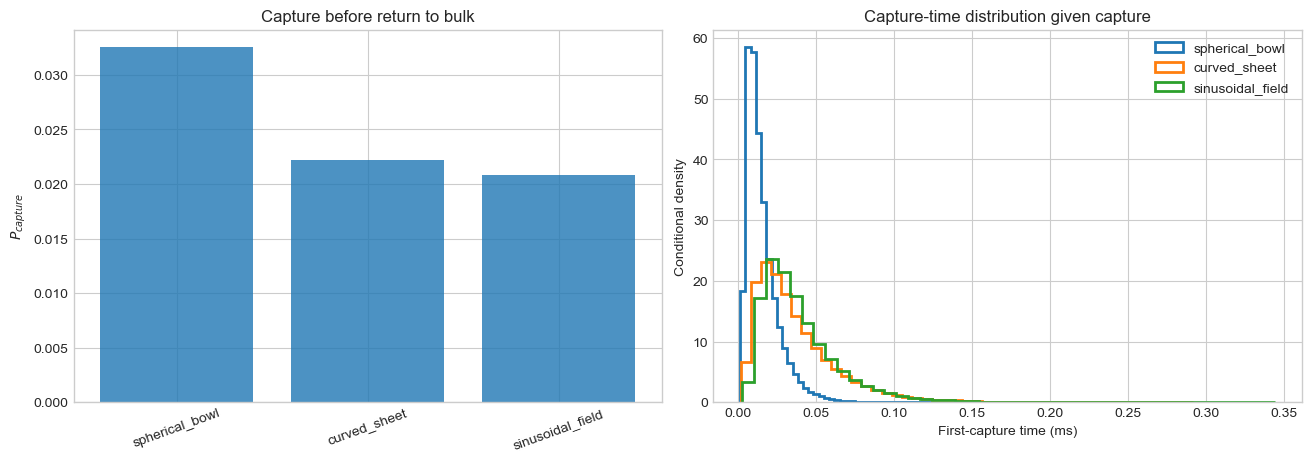

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
axes[0].bar(comparison.index, comparison["capture_probability"], color="tab:blue", alpha=0.8)
axes[0].set(ylabel=r"$P_{capture}$", title="Capture before return to bulk")
axes[0].tick_params(axis="x", rotation=20)
for name, result in capture_results.items():
    times_ms = result.trajectories.loc[result.trajectories["captured"], "capture_time_s"] * 1e3
    if len(times_ms):
        axes[1].hist(times_ms, bins=45, density=True, histtype="step", linewidth=2, label=name)
axes[1].set(xlabel="First-capture time (ms)", ylabel="Conditional density", title="Capture-time distribution given capture")
axes[1].legend()
plt.show()

## 7. Absolute and distance-adjusted spatial capture maps

`fraction_of_captures` describes how captured trajectories are distributed among receptors. `capture_probability_all_trajectories` is the probability that a randomly launched trajectory is captured by each receptor; its sum equals the overall capture probability. `local_capture_enhancement` divides that absolute per-receptor probability by its distance-matched planar expectation.

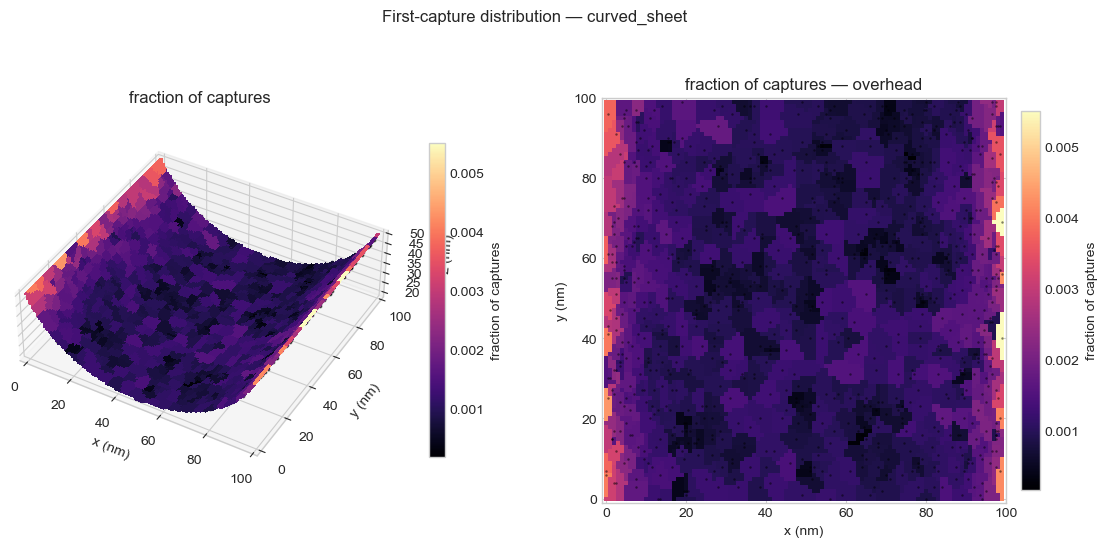

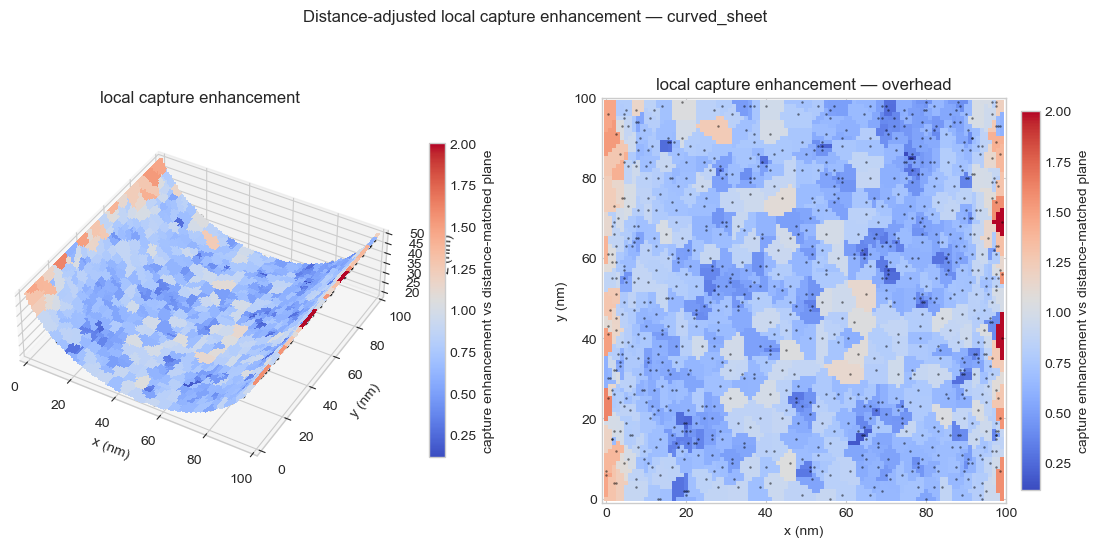

In [48]:
SELECTED_GEOMETRY = RUN_GEOMETRIES[1]
selected = capture_results[SELECTED_GEOMETRY]
CAPTURE_METRIC = "fraction_of_captures"

fig = plt.figure(figsize=(14, 6))
ax_3d = fig.add_subplot(1, 2, 1, projection="3d")
plot_capture_surface_3d(
    selected.derived.geometry, selected.receptor_summary, CAPTURE_METRIC,
    a_m=P.a_m, show_receptors=True, receptor_size=3, ax=ax_3d,
)
ax_3d.view_init(elev=40, azim=-60)
ax_xy = fig.add_subplot(1, 2, 2)
plot_capture_surface_xy(
    selected.derived.geometry, selected.receptor_summary, CAPTURE_METRIC,
    a_m=P.a_m, show_receptors=True, receptor_size=3, ax=ax_xy,
)
fig.suptitle(f"First-capture distribution — {SELECTED_GEOMETRY}")
plt.show()

fig = plt.figure(figsize=(14, 6))
ax_3d = fig.add_subplot(1, 2, 1, projection="3d")
plot_capture_surface_3d(
    selected.derived.geometry, selected.receptor_summary, "local_capture_enhancement",
    a_m=P.a_m, cmap="coolwarm", colorbar_label="capture enhancement vs distance-matched plane",
    show_receptors=True, receptor_size=3, ax=ax_3d,
)
ax_3d.view_init(elev=40, azim=-60)
ax_xy = fig.add_subplot(1, 2, 2)
plot_capture_surface_xy(
    selected.derived.geometry, selected.receptor_summary, "local_capture_enhancement",
    a_m=P.a_m, cmap="coolwarm", colorbar_label="capture enhancement vs distance-matched plane",
    show_receptors=True, receptor_size=3, ax=ax_xy,
)
fig.suptitle(f"Distance-adjusted local capture enhancement — {SELECTED_GEOMETRY}")
plt.show()

/opt/anaconda3/envs/abmenv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


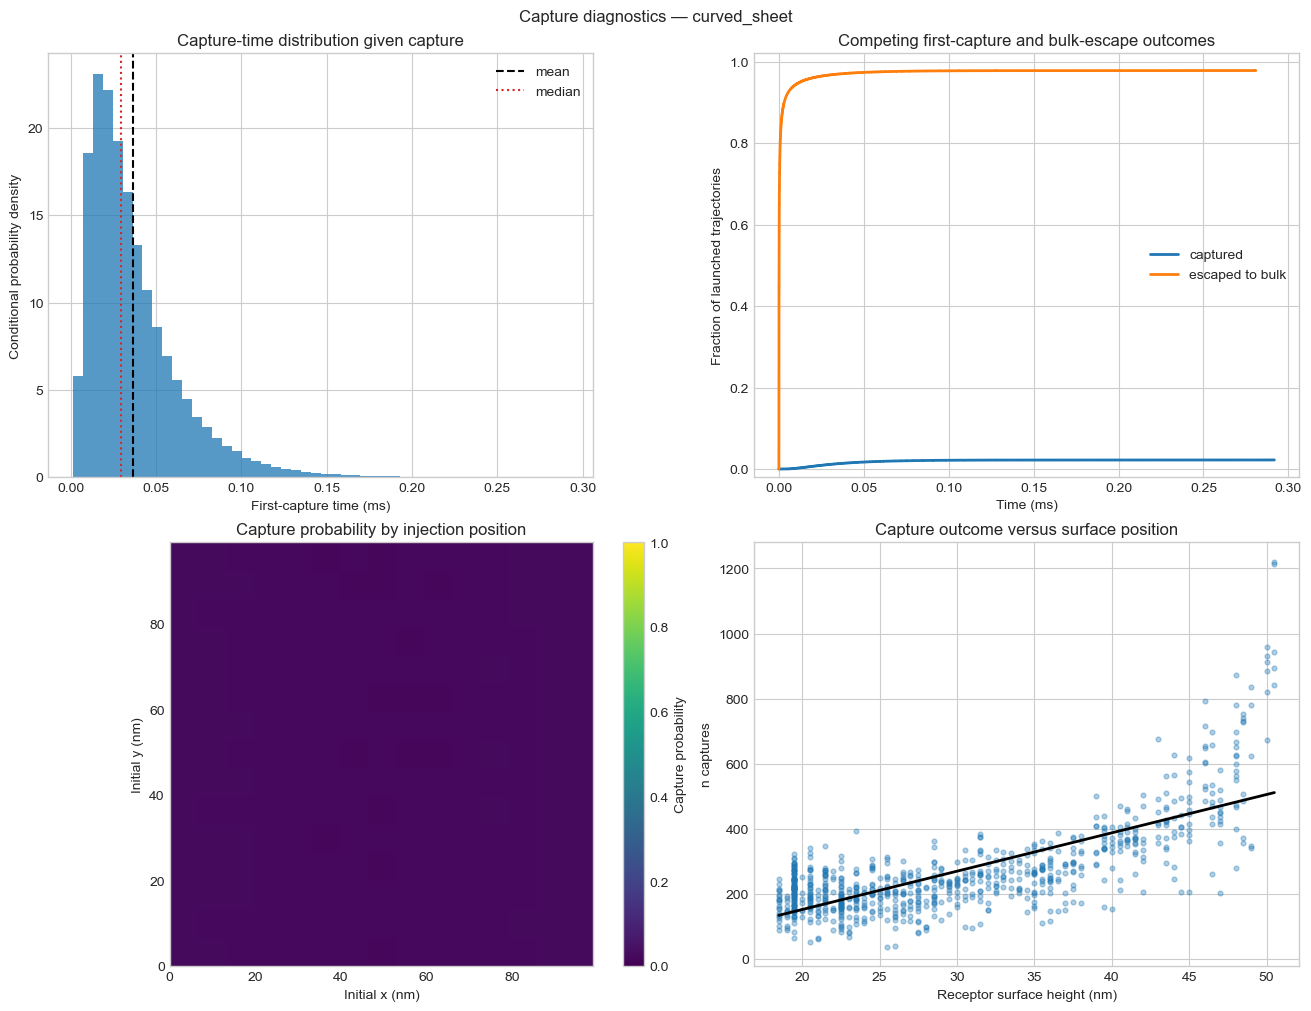

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
plot_capture_time_distribution(selected.trajectories, ax=axes[0, 0])
plot_cumulative_capture_and_escape(selected.trajectories, ax=axes[0, 1])
plot_initial_plane_capture_probability(selected.trajectories, bins=15, ax=axes[1, 0])
plot_capture_vs_surface_height(selected.receptor_summary, metric="n_captures", ax=axes[1, 1])
fig.suptitle(f"Capture diagnostics — {SELECTED_GEOMETRY}")
plt.show()

## 8. Inspect trajectory and receptor-level records

In [46]:
display(selected.trajectories.head())
display(selected.receptor_summary.sort_values("n_captures", ascending=False).head(20))
assert not np.any(selected.trajectories["captured"] & selected.trajectories["escaped"])
assert selected.trajectories[["captured", "escaped", "censored"]].sum(axis=1).eq(1).all()

,trajectory_id,captured,escaped,censored,termination_reason,termination_time_s,capture_time_s,escape_time_s,initial_x_index,initial_y_index,initial_z_index,initial_x_m,initial_y_m,initial_z_m,final_x_m,final_y_m,final_z_m,capturing_receptor_id,capture_face_id,capture_x_m,capture_y_m,capture_z_m,n_receptor_contact_steps,n_binding_attempts
0,0,False,True,False,bulk_escape,6.016667e-07,NaN,6.016667e-07,72,38,74,7.200000e-08,3.800000e-08,7.400000e-08,6.900000e-08,3.300000e-08,7.400000e-08,-1,-1,NaN,NaN,NaN,0,0
1,1,False,True,False,bulk_escape,1.583333e-08,NaN,1.583333e-08,5,12,74,5.000000e-09,1.200000e-08,7.400000e-08,5.000000e-09,1.200000e-08,7.400000e-08,-1,-1,NaN,NaN,NaN,0,0
2,2,False,True,False,bulk_escape,3.641667e-07,NaN,3.641667e-07,60,13,74,6.000000e-08,1.300000e-08,7.400000e-08,6.400000e-08,1.600000e-08,7.400000e-08,-1,-1,NaN,NaN,NaN,0,0
3,3,False,True,False,bulk_escape,4.750000e-06,NaN,4.750000e-06,32,65,74,3.200000e-08,6.500000e-08,7.400000e-08,4.100000e-08,7.900000e-08,7.400000e-08,-1,-1,NaN,NaN,NaN,0,0
4,4,False,True,False,bulk_escape,4.433333e-07,NaN,4.433333e-07,26,27,74,2.600000e-08,2.700000e-08,7.400000e-08,2.700000e-08,2.400000e-08,7.400000e-08,-1,-1,NaN,NaN,NaN,0,0


,receptor_id,source_face_id,surface_x_m,surface_y_m,surface_z_m,release_x_m,release_y_m,release_z_m,n_captures,mean_capture_time_s,median_capture_time_s,mean_contact_steps_before_capture,location_id,label,capture_probability_all_trajectories,fraction_of_captures,injection_to_receptor_distance_nm,planar_capture_probability_at_distance,planar_expected_probability_per_receptor,local_capture_enhancement
1038,1038,22521,7.300000e-08,7.300000e-08,3.950000e-08,7.300000e-08,7.300000e-08,4.000000e-08,867,0.000036,0.000028,1.061130,1038,receptor_1038,0.000087,0.004165,34.0,0.022143,0.000044,1.957701
469,469,17921,2.700000e-08,7.300000e-08,3.950000e-08,2.700000e-08,7.300000e-08,4.000000e-08,843,0.000035,0.000028,1.046263,469,receptor_469,0.000084,0.004050,34.0,0.022143,0.000044,1.903509
71,71,22822,7.600000e-08,7.400000e-08,3.950000e-08,7.600000e-08,7.400000e-08,4.000000e-08,840,0.000036,0.000029,1.042857,71,receptor_71,0.000084,0.004035,34.0,0.022143,0.000044,1.896735
527,527,15348,2.000000e-09,0.000000e+00,3.950000e-08,2.000000e-09,0.000000e+00,4.000000e-08,818,0.000035,0.000028,1.055012,527,receptor_527,0.000082,0.003929,34.0,0.022143,0.000044,1.847058
1023,1023,20194,5.000000e-08,4.600000e-08,3.850000e-08,5.000000e-08,4.600000e-08,3.900000e-08,762,0.000035,0.000028,1.052493,1023,receptor_1023,0.000076,0.003660,35.0,0.021605,0.000043,1.763471
454,454,20549,5.400000e-08,1.000000e-09,3.850000e-08,5.400000e-08,1.000000e-09,3.900000e-08,735,0.000035,0.000028,1.053061,454,receptor_454,0.000073,0.003531,35.0,0.021605,0.000043,1.700985
431,431,23120,7.900000e-08,7.200000e-08,3.750000e-08,7.900000e-08,7.200000e-08,3.800000e-08,722,0.000036,0.000030,1.045706,431,receptor_431,0.000072,0.003468,36.0,0.021092,0.000042,1.711512
362,362,24949,9.800000e-08,1.000000e-09,3.950000e-08,9.800000e-08,1.000000e-09,4.000000e-08,720,0.000036,0.000029,1.047222,362,receptor_362,0.000072,0.003459,34.0,0.022143,0.000044,1.625772
840,840,22272,7.100000e-08,2.400000e-08,3.850000e-08,7.100000e-08,2.400000e-08,3.900000e-08,688,0.000037,0.000030,1.040698,840,receptor_840,0.000069,0.003305,35.0,0.021605,0.000043,1.592215
717,717,20494,5.300000e-08,4.600000e-08,3.750000e-08,5.300000e-08,4.600000e-08,3.800000e-08,681,0.000036,0.000030,1.067548,717,receptor_717,0.000068,0.003271,36.0,0.021092,0.000042,1.614320


## 9. Optional self-contained export

Each folder stores the exact geometry, receptor layout, trajectory outcomes, capture summaries, and parameters required to recreate the plots.

In [10]:
SAVE_RESULTS = False
OUTPUT_ROOT = Path("data/capture_assay")
if SAVE_RESULTS:
    for name, result in capture_results.items():
        saved = export_capture_assay_run(
            result, OUTPUT_ROOT / name,
            run_metadata={
                "geometry": name, "escape_z_m": escape_z_m,
                "initial_xy_m": INITIAL_XY_M,
            },
        )
        print(f"Saved {name} to {saved.resolve()}")

## 10. Reload a previous run without rerunning trajectories

In [11]:
LOAD_PREVIOUS_RUN = False
PREVIOUS_RUN_DIRECTORY = Path("data/capture_assay/spherical_bowl")
if LOAD_PREVIOUS_RUN:
    previous = load_capture_assay_run(PREVIOUS_RUN_DIRECTORY)
    display(previous.condition_summary)
    plot_capture_surface_3d(
        previous.geometry, previous.receptor_summary,
        a_m=previous.params.a_m, show_receptors=True,
    )
    plt.show()